UPC （Universal Product Code）是用來識別每一張**專輯**的獨一無二條碼數字， 數位音樂平台使用國際條碼作為唯一值來識別每一張發行作品。 UPC 為 12- 14 碼的數字。
 

**Unique Key:** ISRC （International standard recording code）是每首**歌曲**獨一無二的身分證字號，為 12 碼的英文數字組合。只要是獨一無二的「音檔」（歌名、版本、藝人需要完全相同）就可以共用同一組 ISRC。

1. exclude shifting data
2. exclude songs without ISRC

In [128]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.2f}'.format
import glob

In [69]:
file_list = glob.glob("*.xlsx")

In [70]:
df_sample = pd.read_excel(file_list[0])

In [71]:
file_list[0]

'2168845_770982_20240701_20240930.xlsx'

In [72]:
print(df_sample.columns)

Index(['Reporting Month', 'Platform', 'Label Name', 'Sales Type',
       'Client Payment Currency', 'Unit Price', 'Mechanical Fee',
       'Gross Revenue', 'Client Share Rate', 'ISRC', 'UPC', 'Track title',
       'Artist Name', 'Release title', 'Country/Region', 'Quantity',
       'Net Revenue', 'Sales Month', 'Release Type', 'Unnamed: 19',
       'Unnamed: 20'],
      dtype='object')


In [73]:
# delete the last two columns which are empty
df_sample = df_sample.iloc[:, :-2]

In [74]:
print(df_sample.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197605 entries, 0 to 197604
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Reporting Month          197605 non-null  object 
 1   Platform                 197605 non-null  object 
 2   Label Name               197605 non-null  object 
 3   Sales Type               197605 non-null  object 
 4   Client Payment Currency  197605 non-null  object 
 5   Unit Price               197604 non-null  float64
 6   Mechanical Fee           197605 non-null  float64
 7   Gross Revenue            197605 non-null  float64
 8   Client Share Rate        197605 non-null  float64
 9   ISRC                     197534 non-null  object 
 10  UPC                      197605 non-null  int64  
 11  Track title              197534 non-null  object 
 12  Artist Name              197605 non-null  object 
 13  Release title            197605 non-null  object 
 14  Coun

In [75]:
# glimpse the data
df_sample.iloc[198:200, :]

,Reporting Month,Platform,Label Name,Sales Type,Client Payment Currency,Unit Price,Mechanical Fee,Gross Revenue,Client Share Rate,ISRC,UPC,Track title,Artist Name,Release title,Country/Region,Quantity,Net Revenue,Sales Month,Release Type
198,01/07/2024,YouTube Official Content,豐華娛樂唱片,Stream,USD,0.00,0.00,0.01,0.80,HK-G63-18-79067,4715202901746,月光像姐兒,汪明荃,娛樂羣英會,Canada,3,0.01,01/07/2024,Music Release
199,01/09/2024,YouTube UGC,豐華娛樂唱片,Stream,USD,0.01,0.00,0.01,0.80,HK-G63-18-96029,4715202900985,從不放棄,鄭少秋,天地男兒,Bulgaria,1,0.00,01/09/2024,Music Release


In [76]:
# convert data type
df_sample['Reporting Month'] = pd.to_datetime(df_sample['Reporting Month'], errors='coerce', format='%d/%m/%Y')
df_sample['UPC'] = df_sample['UPC'].astype(str)
df_sample['Quantity'] = pd.to_numeric(df_sample['Quantity'], errors='coerce')
df_sample['Net Revenue'] = pd.to_numeric(df_sample['Net Revenue'], errors='coerce')
# df_sample['Sales Month'] = pd.to_datetime(df_sample['Sales Month'], errors='coerce')


In [77]:
# check weird data
df_sample[df_sample['ISRC'].isin(['HK-G63-18-91020','HK-G63-18-90032'])]

,Reporting Month,Platform,Label Name,Sales Type,Client Payment Currency,Unit Price,Mechanical Fee,Gross Revenue,Client Share Rate,ISRC,UPC,Track title,Artist Name,Release title,Country/Region,Quantity,Net Revenue,Sales Month,Release Type
1032,2024-09-01,YouTube Official Content,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-91020,4715202900787,晴天,陰天,下雨天,溫兆倫,NaN,NaN,1,0.00
1757,2024-07-01,YouTube Official Content,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-90032,4715202900763,兒歌,兒歌,溫兆倫,"走路新郎哥 / 兒歌, 兒歌",NaN,3.00,0.00,01/07/2024
2477,2024-08-01,YouTube UGC,豐華娛樂唱片,Stream,USD,0.01,0.00,0.01,0.80,HK-G63-18-90032,4715202900763,兒歌,兒歌,溫兆倫,"走路新郎哥 / 兒歌, 兒歌",NaN,1.00,0.00,01/08/2024
3691,2024-07-01,Apple Music,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-90032,4715202900763,兒歌,兒歌,溫兆倫,"走路新郎哥 / 兒歌, 兒歌",NaN,1.00,0.00,01/07/2024
4215,2024-09-01,YouTube Official Content,豐華娛樂唱片,Stream,USD,0.00,0.00,0.01,0.80,HK-G63-18-90032,4715202900763,兒歌,兒歌,溫兆倫,"走路新郎哥 / 兒歌, 兒歌",NaN,3.00,0.01,01/09/2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194227,2024-07-01,Spotify,豐華娛樂唱片,Stream,USD,0.00,0.00,0.01,0.80,HK-G63-18-91020,4715202900787,晴天,陰天,下雨天,溫兆倫,NaN,NaN,3,0.01
196654,2024-09-01,Spotify,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-91020,4715202900787,晴天,陰天,下雨天,溫兆倫,NaN,NaN,1,0.00
197011,2024-09-01,Apple Music,豐華娛樂唱片,Stream,USD,0.01,0.00,0.01,0.80,HK-G63-18-90032,4715202900763,兒歌,兒歌,溫兆倫,"走路新郎哥 / 兒歌, 兒歌",NaN,1.00,0.01,01/09/2024
197219,2024-09-01,Apple Music,豐華娛樂唱片,Stream,USD,0.01,0.00,0.01,0.80,HK-G63-18-91020,4715202900787,晴天,陰天,下雨天,溫兆倫,NaN,NaN,1,0.00


In [78]:
# check currency is in USD
df_sample['Client Payment Currency'].unique()

array(['USD'], dtype=object)

In [79]:
# check missing values
print(df_sample.isnull().sum())

Reporting Month              0
Platform                     0
Label Name                   0
Sales Type                   0
Client Payment Currency      0
Unit Price                   1
Mechanical Fee               0
Gross Revenue                0
Client Share Rate            0
ISRC                        71
UPC                          0
Track title                 71
Artist Name                  0
Release title                0
Country/Region               0
Quantity                   235
Net Revenue                124
Sales Month                  0
Release Type                 0
dtype: int64


In [80]:
# drop rows with missing values in 'Quantity' and 'ISRC' columns
df_sample_clean = df_sample.dropna(subset = ['Quantity', 'ISRC']).copy()
print(df_sample_clean.isnull().sum())

Reporting Month            0
Platform                   0
Label Name                 0
Sales Type                 0
Client Payment Currency    0
Unit Price                 1
Mechanical Fee             0
Gross Revenue              0
Client Share Rate          0
ISRC                       0
UPC                        0
Track title                0
Artist Name                0
Release title              0
Country/Region             0
Quantity                   0
Net Revenue                0
Sales Month                0
Release Type               0
dtype: int64


In [81]:
df_sample_clean[df_sample_clean['Unit Price'].isna()]

,Reporting Month,Platform,Label Name,Sales Type,Client Payment Currency,Unit Price,Mechanical Fee,Gross Revenue,Client Share Rate,ISRC,UPC,Track title,Artist Name,Release title,Country/Region,Quantity,Net Revenue,Sales Month,Release Type
22310,2024-07-01,iTunes,豐華娛樂唱片,Download,USD,NaN,0.00,0.00,0.80,HK-G63-18-77005,4715202900497,乘風破浪,楊詩蒂,狂潮,Hong Kong,0.00,0.00,01/07/2024,Music Release


In [82]:
# summary statistics for numeric columns
print(df_sample_clean.describe())

                     Reporting Month  Unit Price  Mechanical Fee  \
count                         197299   197298.00       197299.00   
mean   2024-08-01 10:26:43.677667072        0.00            0.00   
min              2024-07-01 00:00:00       -0.00            0.00   
25%              2024-07-01 00:00:00        0.00            0.00   
50%              2024-08-01 00:00:00        0.00            0.00   
75%              2024-09-01 00:00:00        0.00            0.00   
max              2024-09-01 00:00:00        0.95            0.99   
std                              NaN        0.04            0.00   

       Gross Revenue  Client Share Rate  Quantity  Net Revenue  
count      197299.00          197299.00 197299.00    197299.00  
mean            0.18               0.81    157.75         0.14  
min           -32.11               0.80     -1.00       -32.11  
25%             0.00               0.80      1.00         0.00  
50%             0.00               0.80      3.00         0.00

In [83]:
# Check if all files have the same columns
for file in file_list:
    cols = pd.read_excel(file, nrows=0).columns.tolist()
    print(f"File: {file} | Columns: {len(cols)}")
    # If this prints different lengths, you know you have a cleaning task ahead

File: 2168845_770982_20240701_20240930.xlsx | Columns: 19
File: 2168833_770982_20220101_20220331.xlsx | Columns: 19
File: 2168852_770982_20250701_20250930.xlsx | Columns: 19
File: 2168843_770982_20240101_20240331.xlsx | Columns: 19
File: 2168838_770982_20221001_20221231.xlsx | Columns: 19
File: 2168844_770982_20240401_20240630.xlsx | Columns: 19
File: 2168846_770982_20241001_20241231.xlsx | Columns: 19
File: 2168835_770982_20220401_20220630.xlsx | Columns: 19
File: missing_data_report.xlsx | Columns: 20
File: 2168840_770982_20230401_20230630.xlsx | Columns: 19
File: 2168851_770982_20250401_20250630.xlsx | Columns: 19
File: 2168842_770982_20231001_20231231.xlsx | Columns: 19
File: 2168839_770982_20230101_20230331.xlsx | Columns: 19
File: 2168849_770982_20250101_20250331.xlsx | Columns: 19
File: 2168837_770982_20220701_20220930.xlsx | Columns: 19
File: 2168841_770982_20230701_20230930.xlsx | Columns: 19


In [84]:
# count ISRC occurrences
df_sample_clean['ISRC'].value_counts()

ISRC
HK-G63-18-78001    2610
HK-G63-18-82039    2600
HK-G63-18-95001    2239
HK-G63-18-79001    2078
HK-G63-18-80001    2009
                   ... 
HK-G63-18-82036       1
HK-W63-18-00072       1
HK-W63-20-30079       1
HK-G63-18-82034       1
HK-W63-18-00135       1
Name: count, Length: 1324, dtype: int64

In [85]:
# see top click song
df_sample_clean[df_sample_clean['ISRC'] == 'HK-G63-18-78001']

,Reporting Month,Platform,Label Name,Sales Type,Client Payment Currency,Unit Price,Mechanical Fee,Gross Revenue,Client Share Rate,ISRC,UPC,Track title,Artist Name,Release title,Country/Region,Quantity,Net Revenue,Sales Month,Release Type
248,2024-08-01,Spotify,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-78001,4715202901173,小李飛刀,羅文,小李飛刀,Morocco,4.00,0.00,01/07/2024,Music Release
262,2024-08-01,Facebook / Instagram,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-78001,4715202901043,小李飛刀,羅文,娛樂千禧精選,Finland,7.00,0.00,01/07/2024,Music Release
279,2024-08-01,Spotify,豐華娛樂唱片,Stream,USD,0.00,0.00,0.06,0.80,HK-G63-18-78001,4715202901173,小李飛刀,羅文,小李飛刀,"Korea, Republic Of",20.00,0.05,01/07/2024,Music Release
292,2024-07-01,Apple Music,豐華娛樂唱片,Stream,USD,0.00,0.00,15.10,0.80,HK-G63-18-78001,4715202901173,小李飛刀,羅文,小李飛刀,China Mainland,4715.00,12.08,01/07/2024,Music Release
365,2024-07-01,Spotify,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-78001,4715202901173,小李飛刀,羅文,小李飛刀,Ukraine,3.00,0.00,01/06/2024,Music Release
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197154,2024-08-01,YouTube UGC,豐華娛樂唱片,Stream,USD,0.00,0.00,0.01,0.80,HK-G63-18-78001,4715202901173,小李飛刀,羅文,小李飛刀,Belgium,3.00,0.01,01/08/2024,Music Release
197173,2024-09-01,Facebook / Instagram,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-78001,4715202901043,小李飛刀,羅文,娛樂千禧精選,French Guiana,1.00,0.00,01/08/2024,Music Release
197270,2024-08-01,YouTube UGC,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-78001,4715202901173,小李飛刀,羅文,小李飛刀,Lao People S Democratic Republic,1.00,0.00,01/08/2024,Music Release
197300,2024-09-01,YouTube Official Content,豐華娛樂唱片,Stream,USD,0.00,0.00,0.07,0.80,HK-G63-18-78001,4715202900701,小李飛刀,羅文,電視主題金曲精選,Philippines,38.00,0.06,01/09/2024,Music Release


In [92]:
# # add year and month columns for later analysis
df_sample_clean['Reporting Year'] = df_sample_clean['Reporting Month'].dt.year
df_sample_clean['Reporting Month Num'] = df_sample_clean['Reporting Month'].dt.month

## Calculate Revenue and Click

In [93]:
print(df_sample_clean.columns)

Index(['Reporting Month', 'Platform', 'Label Name', 'Sales Type',
       'Client Payment Currency', 'Unit Price', 'Mechanical Fee',
       'Gross Revenue', 'Client Share Rate', 'ISRC', 'UPC', 'Track title',
       'Artist Name', 'Release title', 'Country/Region', 'Quantity',
       'Net Revenue', 'Sales Month', 'Release Type', 'Reporting Year',
       'Reporting Month Num'],
      dtype='object')


In [94]:
revenue_by_song = (
    df_sample_clean
    .groupby('ISRC')
    .agg(
        song=('Track title','first'),
        artist=('Artist Name','first'),
        click=('Quantity','sum'),
        revenue=('Net Revenue','sum')
    )
    .reset_index()
)
revenue_by_song = revenue_by_song.sort_values('revenue', ascending=False)


In [95]:
total_revenue = revenue_by_song['revenue'].sum()
revenue_by_song_top30 = revenue_by_song.head(30).copy()
revenue_by_song_top30['rev_share'] = revenue_by_song_top30['revenue']/ total_revenue
revenue_by_song_top30

,ISRC,song,artist,click,revenue,rev_share
873,HK-G63-18-95001,笑看風雲,鄭少秋,10107494.00,4458.49,0.16
609,HK-G63-18-84087,夜夜痴纏,麥潔文,415294.00,2359.60,0.09
751,HK-G63-18-92001,隨緣,溫兆倫,1327155.00,1712.84,0.06
513,HK-G63-18-82039,萬水千山總是情,汪明荃,1711544.00,1382.26,0.05
248,HK-G63-18-78001,小李飛刀,羅文,872060.00,788.44,0.03
284,HK-G63-18-78049,倚天屠龍記,鄭少秋,542738.00,631.42,0.02
296,HK-G63-18-79001,楚留香,鄭少秋,630020.00,567.60,0.02
58,HK-G63-18-60023,相認,"任劍輝, 白雪仙",237059.00,501.87,0.02
155,HK-G63-18-76001,書劍恩仇錄,鄭少秋,138087.00,486.82,0.02
290,HK-G63-18-78055,誓要入刀山,鄭少秋,472165.00,451.70,0.02


In [96]:
print(revenue_by_song['click'].sum())

31124595.0


In [97]:
revenue_by_month = (
    df_sample_clean
    .groupby('Reporting Month Num')
    .agg(
        click=('Quantity','sum'),
        revenue=('Net Revenue','sum')
    )
    .reset_index()
)

revenue_by_month

,Reporting Month Num,click,revenue
0,7,10175741.00,8720.25
1,8,9877917.00,10016.11
2,9,11070937.00,9007.12


In [98]:
print(revenue_by_month['click'].sum())

31124595.0


In [99]:
df_sample_clean.shape

(197299, 21)

In [100]:
revenue_by_month_song = (
    df_sample_clean
    .groupby(['ISRC', 'Reporting Month Num'])
    .agg(
        song=('Track title','first'),
        artist=('Artist Name','first'),
        click=('Quantity','sum'),
        revenue=('Net Revenue','sum')
    )
    .reset_index()
)
revenue_by_month_song

,ISRC,Reporting Month Num,song,artist,click,revenue
0,FR-W24-21-47010,7,汪明荃〈萬水千山總是情〉｜動態歌詞MV,CROWN 娛樂音樂,231.00,0.41
1,FR-W24-21-47010,8,汪明荃〈萬水千山總是情〉｜動態歌詞MV,CROWN 娛樂音樂,169.00,0.20
2,FR-W24-21-47010,9,汪明荃〈萬水千山總是情〉｜動態歌詞MV,CROWN 娛樂音樂,162.00,0.27
3,FR-W24-21-51988,7,溫兆倫、陳松伶〈田園春夢〉MV｜娛樂唱片,CROWN 娛樂音樂,41.00,0.07
4,FR-W24-21-51988,8,溫兆倫、陳松伶〈田園春夢〉MV｜娛樂唱片,CROWN 娛樂音樂,22.00,0.12
...,...,...,...,...,...,...
3918,HK-W63-20-30099,8,唐吉珂德,麥潔文,3.00,0.00
3919,HK-W63-20-30099,9,唐吉珂德,麥潔文,13.00,0.03
3920,HK-W63-20-30101,7,火燒圓明園,鄭少秋,14.00,0.10
3921,HK-W63-20-30101,8,火燒圓明園,鄭少秋,5.00,0.01


## Merge all files

### Data Cleaning

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
# import numpy as np

from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import StrMethodFormatter

In [102]:
all_data = []
for file in file_list: 
    temp_df = pd.read_excel(file, usecols="A:S")
    # add a column to track which file the data came from
    temp_df['source_file'] = file 
    all_data.append(temp_df)

# Combine into one master DataFrame

df = pd.concat(all_data, ignore_index=True)
print(df.isnull().sum())

Reporting Month                0
Platform                       0
Label Name                     0
Sales Type                     0
Client Payment Currency        0
Unit Price                  1315
Mechanical Fee                 0
Gross Revenue                  0
Client Share Rate              0
ISRC                        4075
UPC                            0
Track title                 4075
Artist Name                    0
Release title                  0
Country/Region                 0
Quantity                   25544
Net Revenue                14716
Sales Month                25544
Release Type                   0
source_file                    0
dtype: int64


In [103]:
# check how many rows we have from each file
print(df['source_file'].value_counts())

source_file
2168851_770982_20250401_20250630.xlsx    239442
2168852_770982_20250701_20250930.xlsx    231163
2168843_770982_20240101_20240331.xlsx    211013
2168846_770982_20241001_20241231.xlsx    210616
2168842_770982_20231001_20231231.xlsx    207703
2168844_770982_20240401_20240630.xlsx    207159
2168839_770982_20230101_20230331.xlsx    198441
2168849_770982_20250101_20250331.xlsx    197695
2168845_770982_20240701_20240930.xlsx    197605
2168841_770982_20230701_20230930.xlsx    184606
2168840_770982_20230401_20230630.xlsx    165315
2168837_770982_20220701_20220930.xlsx    160553
2168835_770982_20220401_20220630.xlsx    159550
2168838_770982_20221001_20221231.xlsx    154153
2168833_770982_20220101_20220331.xlsx    153618
missing_data_report.xlsx                  28804
Name: count, dtype: int64


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2907436 entries, 0 to 2907435
Data columns (total 20 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Reporting Month          object 
 1   Platform                 object 
 2   Label Name               object 
 3   Sales Type               object 
 4   Client Payment Currency  object 
 5   Unit Price               float64
 6   Mechanical Fee           float64
 7   Gross Revenue            float64
 8   Client Share Rate        float64
 9   ISRC                     object 
 10  UPC                      int64  
 11  Track title              object 
 12  Artist Name              object 
 13  Release title            object 
 14  Country/Region           object 
 15  Quantity                 object 
 16  Net Revenue              object 
 17  Sales Month              object 
 18  Release Type             object 
 19  source_file              object 
dtypes: float64(4), int64(1), object(15)
memory usa

In [105]:
# convert data type
df['Reporting Month'] = pd.to_datetime(df['Reporting Month'], errors='coerce', format='%d/%m/%Y')
df['UPC'] = df['UPC'].astype(str)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Net Revenue'] = pd.to_numeric(df['Net Revenue'], errors='coerce')
df['Sales Month'] = pd.to_datetime(df['Sales Month'], errors='coerce')


In [106]:
df.isnull().sum()

# check missing values ratio
# df.isnull().mean()

Reporting Month                0
Platform                       0
Label Name                     0
Sales Type                     0
Client Payment Currency        0
Unit Price                  1315
Mechanical Fee                 0
Gross Revenue                  0
Client Share Rate              0
ISRC                        4075
UPC                            0
Track title                 4075
Artist Name                    0
Release title                  0
Country/Region                 0
Quantity                   31930
Net Revenue                18395
Sales Month                31934
Release Type                   0
source_file                    0
dtype: int64

In [107]:
df['Country/Region'].unique()

array(['Viet Nam', 'Philippines', 'Slovakia', 'Sweden', 'Colombia',
       'Turkey', 'India', 'Iraq', 'France', 'Azerbaijan', 'Indonesia',
       'Yemen', 'China Mainland', 'Poland', 'Venezuela',
       'Brunei Darussalam', 'Japan', 'Pakistan', 'Australia',
       'Papua New Guinea', 'Ireland', 'Thailand', 'Austria', 'Italy',
       'United Arab Emirates', 'Spain', 'United Kingdom', 'Argentina',
       'Macao', 'Mexico', 'Taiwan', 'New Zealand', 'Korea, Republic Of',
       'United States', 'Panama', 'Saudi Arabia', 'Norway', 'Georgia',
       'South Africa', 'Finland', 'Bangladesh', 'Nigeria', 'Kazakhstan',
       'Costa Rica', 'Armenia', 'Cyprus', 'Dominican Republic', 'Denmark',
       'Hong Kong', 'Belgium', 'French Guiana', 'Bolivia', 'Malaysia',
       'Guatemala', 'Canada', 'Ukraine', 'Guyana', 'Bulgaria', 'Germany',
       'Cambodia', 'Netherlands', 'Paraguay', 'Chile', 'Brazil',
       'Romania', 'Peru', 'Sri Lanka', 'Czech Republic',
       'Turks And Caicos Islands', 'Egypt'

In [108]:
# export rows with missing values to a separate Excel file for review
missing_mask = df['Quantity'].isna() | df['ISRC'].isna()
df_missing = df[missing_mask].copy()
df_missing.to_excel('missing_data_report.xlsx', index=False)
print(f"Number of rows with missing data: {df_missing.shape[0]}")

Number of rows with missing data: 36005


In [109]:
# remove missing values in 'Quantity' and 'ISRC' columns
df_cleaned = df.dropna(subset = ['Quantity', 'ISRC']).copy()
print(df_cleaned.isnull().sum())

Reporting Month               0
Platform                      0
Label Name                    0
Sales Type                    0
Client Payment Currency       0
Unit Price                 1310
Mechanical Fee                0
Gross Revenue                 0
Client Share Rate             0
ISRC                          0
UPC                           0
Track title                   0
Artist Name                   0
Release title                 0
Country/Region                0
Quantity                      0
Net Revenue                   0
Sales Month                   4
Release Type                  0
source_file                   0
dtype: int64


In [110]:
# add year and month columns for later analysis
# df_cleaned['Reporting Year'] = df_cleaned['Reporting Month'].dt.year
# df_cleaned['Reporting Month Num'] = df_cleaned['Reporting Month'].dt.month

# df_cleaned['YearMonth'] = (
#     df_cleaned['Reporting Year'].astype(str) 
#     + '-' 
#     + df_cleaned['Reporting Month Num'].astype(str).str.zfill(2)
#     )

df_cleaned['YearMonth'] = df_cleaned['Reporting Month'].dt.to_period('M').astype(str)

In [111]:
df_cleaned.head(3)

,Reporting Month,Platform,Label Name,Sales Type,Client Payment Currency,Unit Price,Mechanical Fee,Gross Revenue,Client Share Rate,ISRC,...,Track title,Artist Name,Release title,Country/Region,Quantity,Net Revenue,Sales Month,Release Type,source_file,YearMonth
0,2024-07-01,YouTube Official Content,CROWN MUSIC ENTERTAINMENT (HK) LIMITED,Stream,USD,0.00,0.00,0.00,0.80,HK-W63-18-00308,...,胡不歸之哭墳,薛覺先,薛覺先〈胡不歸之哭墳〉MV｜娛樂唱片,Viet Nam,2.00,0.00,2024-01-07,Music Video,2168845_770982_20240701_20240930.xlsx,2024-07
1,2024-07-01,Facebook / Instagram,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-77005,...,乘風破浪,楊詩蒂,狂潮,Philippines,4.00,0.00,2024-01-06,Music Release,2168845_770982_20240701_20240930.xlsx,2024-07
2,2024-07-01,YouTube Official Content,豐華娛樂唱片,Stream,USD,0.00,0.00,0.01,0.80,HK-G63-18-96029,...,從不放棄,鄭少秋,天地男兒,Slovakia,2.00,0.01,2024-01-07,Music Release,2168845_770982_20240701_20240930.xlsx,2024-07


### Monthly Revenue

In [112]:
revenue_by_month = (
    df_cleaned
    .groupby(['YearMonth'])
    .agg(
        click=('Quantity','sum'),
        revenue=('Net Revenue','sum')
    )
    .reset_index()
)

revenue_by_month

,YearMonth,click,revenue
0,2022-01,6771695.00,5046.37
1,2022-02,5993314.00,4756.95
2,2022-03,5725879.00,5793.99
3,2022-04,6207162.00,6839.88
4,2022-05,5300658.00,6083.30
5,2022-06,5266271.00,6375.31
6,2022-07,5683403.00,6972.46
7,2022-08,6364686.00,5598.70
8,2022-09,4060718.00,5701.33
9,2022-10,4622643.00,6449.87


In [113]:
# million formatter for better visualization

def million_format(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.0f}K'
    return str(int(x))

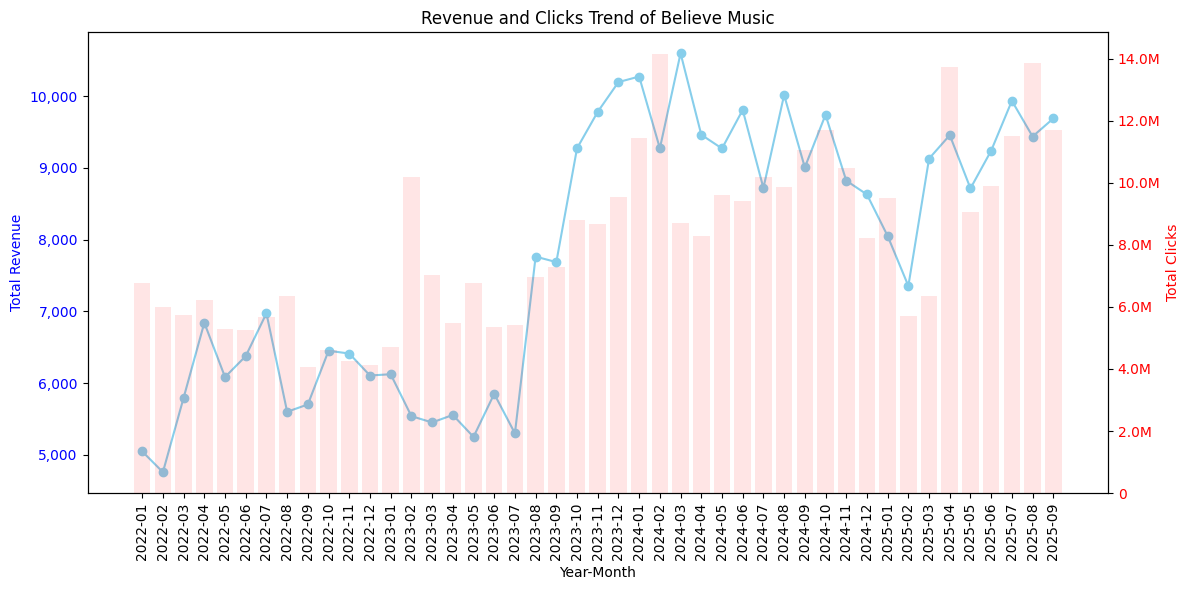

In [127]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# y-axis (left) - Revenue
ax1.plot(revenue_by_month['YearMonth'], revenue_by_month['revenue'], color='skyblue', label='Revenue', marker = 'o')
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Total Revenue', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=90) 

# y-axis (right) - Clicks
ax2 = ax1.twinx()
ax2.bar(revenue_by_month['YearMonth'], revenue_by_month['click'], color='red', label='Clicks', alpha=0.1)
ax2.set_ylabel('Total Clicks', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(FuncFormatter(million_format))

plt.title('Revenue and Clicks Trend of Believe Music')
fig.tight_layout()
plt.show()

### Revenue by Song

In [115]:
revenue_by_song = (
    df_cleaned
    .groupby('ISRC')
    .agg(
        song=('Track title','first'),
        artist=('Artist Name','first'),
        album=('Release title','first'),
        click=('Quantity','sum'),
        revenue=('Net Revenue','sum')
    )
    .reset_index()
)
revenue_by_song = revenue_by_song.sort_values('revenue', ascending=False)
revenue_by_song

,ISRC,song,artist,album,click,revenue
901,HK-G63-18-95001,笑看風雲,鄭少秋,笑看風雲,103144542.00,59042.26
541,HK-G63-18-82039,萬水千山總是情,汪明荃,娛樂千禧精選,31149257.00,22947.18
779,HK-G63-18-92001,隨緣,溫兆倫,投入生命,17762231.00,19097.09
317,HK-G63-18-78055,誓要入刀山,鄭少秋,倚天屠龍記,6086531.00,10588.81
275,HK-G63-18-78001,小李飛刀,羅文,小李飛刀,10241529.00,10277.19
...,...,...,...,...,...,...
1889,HK-W63-20-10761,家變,羅文,羅文〈家變〉封面MV｜娛樂唱片,1.00,0.00
2155,HK-W63-20-11077,落花淚影,張德蘭,張德蘭〈落花淚影〉封面MV｜娛樂唱片,1.00,0.00
1898,HK-W63-20-10771,魔劍俠情,羅文,羅文〈魔劍俠情〉封面MV｜娛樂唱片,1.00,0.00
2260,HK-W63-20-11234,我愛的女人,溫兆倫,溫兆倫〈我愛的女人〉封面MV｜娛樂唱片,1.00,0.00


In [116]:
# find the top songs
ntop = 20
total_rev = revenue_by_song['revenue'].sum()
revenue_by_song_top = revenue_by_song.head(ntop).copy()
revenue_by_song_top['rev_share'] = revenue_by_song_top['revenue']/ total_rev
top_song_list = revenue_by_song_top['ISRC'].tolist()

print(f"Top {ntop} songs contribute to {revenue_by_song_top['rev_share'].sum():.2%} of total revenue.")
revenue_by_song_top

Top 20 songs contribute to 57.44% of total revenue.


,ISRC,song,artist,album,click,revenue,rev_share
901,HK-G63-18-95001,笑看風雲,鄭少秋,笑看風雲,103144542.00,59042.26,0.17
541,HK-G63-18-82039,萬水千山總是情,汪明荃,娛樂千禧精選,31149257.00,22947.18,0.07
779,HK-G63-18-92001,隨緣,溫兆倫,投入生命,17762231.00,19097.09,0.05
317,HK-G63-18-78055,誓要入刀山,鄭少秋,倚天屠龍記,6086531.00,10588.81,0.03
275,HK-G63-18-78001,小李飛刀,羅文,小李飛刀,10241529.00,10277.19,0.03
323,HK-G63-18-79001,楚留香,鄭少秋,鄭少秋精選,9733654.00,8731.42,0.02
389,HK-G63-18-80001,用愛將心偷 千王之王主题曲,汪明荃,電視主題金曲精選,14581259.00,7742.64,0.02
419,HK-G63-18-80037,輪流轉,鄭少秋,鄭少秋精選,2521692.00,7031.55,0.02
85,HK-G63-18-60023,相認,"任劍輝, 白雪仙",帝女花,1842426.00,6639.09,0.02
915,HK-G63-18-95019,天地情緣,溫兆倫,國語最佳精選輯,10100668.00,6610.19,0.02


In [117]:
top_song_list

['HK-G63-18-95001',
 'HK-G63-18-82039',
 'HK-G63-18-92001',
 'HK-G63-18-78055',
 'HK-G63-18-78001',
 'HK-G63-18-79001',
 'HK-G63-18-80001',
 'HK-G63-18-80037',
 'HK-G63-18-60023',
 'HK-G63-18-95019',
 'HK-G63-18-78049',
 'HK-G63-18-91029',
 'HK-G63-18-96029',
 'HK-G63-18-78015',
 'HK-G63-18-80013',
 'HK-G63-18-74001',
 'HK-G63-18-84087',
 'HK-G63-18-91016',
 'HK-G63-18-76001',
 'HK-G63-18-77021']

In [118]:
len(top_song_list)

20

In [119]:
revenue_by_song_per_month = (
    df_cleaned
    .groupby(['ISRC', 'YearMonth'])
    .agg(
        song=('Track title','first'),
        artist=('Artist Name','first'),
        click=('Quantity','sum'),
        revenue=('Net Revenue','sum')
    )
    .reset_index()
)
revenue_by_song_per_month = revenue_by_song_per_month.sort_values(['YearMonth', 'ISRC'])
revenue_by_song_per_month

,ISRC,YearMonth,song,artist,click,revenue
276,FR-W24-21-65886,2022-01,〈節目介紹〉MV｜娛樂唱片,沈殿霞,2.00,0.00
414,HK-G63-18-01001,2022-01,心事有誰知,鄭少秋,171.00,0.41
459,HK-G63-18-01002,2022-01,今晚躺進我臂彎,鄭少秋,49.00,0.16
504,HK-G63-18-01003,2022-01,大時代過客,鄭少秋,2320.00,6.26
549,HK-G63-18-01004,2022-01,問江山,鄭少秋,924.00,3.26
...,...,...,...,...,...,...
63821,HK-W63-20-30095,2025-09,倚天屠龍記,羅文,8.00,0.03
63866,HK-W63-20-30096,2025-09,舊侶難忘,羅文,11.00,0.03
63911,HK-W63-20-30097,2025-09,山伯臨終,羅文,17.00,0.06
63995,HK-W63-20-30099,2025-09,唐吉珂德,麥潔文,2.00,0.00


In [120]:
# song name consistency check
song_counts = revenue_by_song_per_month.groupby('ISRC')['song'].nunique()
isrc_name_details = revenue_by_song_per_month.groupby('ISRC')['song'].unique()
isrc_name_details[song_counts > 1]


ISRC
HK-G63-18-74008                 [好彩天到SUNDAY, 好彩天到sunday]
HK-G63-18-75021                               [董小宛, 董小苑]
HK-G63-18-75042                        [清宮殘夢主題曲音樂, 清宮殘夢]
HK-G63-18-77031                    [梁山伯與祝英台, 梁山伯與祝英台主題曲]
HK-G63-18-78012                       [小李飛刀 主題曲音樂, 小李飛刀]
HK-G63-18-78024                            [陸小鳳 伴奏, 陸小鳳]
HK-G63-18-79002                         [OH GAL, Oh Gal]
HK-G63-18-79012                            [楚留香, 楚留香 伴奏]
HK-G63-18-79036                        [近代豪俠傳, 近代豪俠傳 伴奏]
HK-G63-18-80001    [用愛將心偷 千王之王主题曲, 用愛將心偷 千王之王主題曲, 用愛將心偷]
HK-G63-18-80002                  [寧願給你欺騙 千王之王插曲, 寧願給你欺騙]
HK-G63-18-80004                          [歸帆 千王之王插曲, 歸帆]
HK-G63-18-80006                      [情枷愛鎖 千王之王插曲, 情枷愛鎖]
HK-G63-18-91016           [從未試過擁有 無線電視劇《今生無悔》插曲, 從未試過擁有]
HK-G63-18-91018              [賭這一份愛 電影《表姐你玩野》主題曲, 賭這一份愛]
HK-G63-18-91019                  [想你 無線電視劇《忠奸老實人》插曲, 想你]
HK-W63-18-00027                            [相聚一刻, 賭這一份愛]
HK-W63-18-00097           

In [121]:
# update song names for those ISRCs with multiple names
# 建立一個 ISRC 對應 標準歌名的字典
standard_names = revenue_by_song_per_month.groupby('ISRC')['song'].agg(lambda x: x.value_counts().index[0])

# 將標準歌名對應回去原始資料 ＆ shorten song name for better visualization
revenue_by_song_per_month['standard_song'] = revenue_by_song_per_month['ISRC'].map(standard_names).str.slice(0, 10)

In [122]:
revenue_by_song_per_month

,ISRC,YearMonth,song,artist,click,revenue,standard_song
276,FR-W24-21-65886,2022-01,〈節目介紹〉MV｜娛樂唱片,沈殿霞,2.00,0.00,〈節目介紹〉MV｜娛
414,HK-G63-18-01001,2022-01,心事有誰知,鄭少秋,171.00,0.41,心事有誰知
459,HK-G63-18-01002,2022-01,今晚躺進我臂彎,鄭少秋,49.00,0.16,今晚躺進我臂彎
504,HK-G63-18-01003,2022-01,大時代過客,鄭少秋,2320.00,6.26,大時代過客
549,HK-G63-18-01004,2022-01,問江山,鄭少秋,924.00,3.26,問江山
...,...,...,...,...,...,...,...
63821,HK-W63-20-30095,2025-09,倚天屠龍記,羅文,8.00,0.03,倚天屠龍記
63866,HK-W63-20-30096,2025-09,舊侶難忘,羅文,11.00,0.03,舊侶難忘
63911,HK-W63-20-30097,2025-09,山伯臨終,羅文,17.00,0.06,山伯臨終
63995,HK-W63-20-30099,2025-09,唐吉珂德,麥潔文,2.00,0.00,唐吉珂德


In [123]:
revenue_by_song_per_month.groupby('ISRC')['standard_song'].nunique().sort_values(ascending=False)

ISRC
FR-W24-20-63594    1
HK-W63-20-10341    1
HK-W63-20-10344    1
HK-W63-20-10345    1
HK-W63-20-10346    1
                  ..
HK-G63-18-92020    1
HK-G63-18-92021    1
HK-G63-18-92022    1
HK-G63-18-92023    1
HK-W63-20-30101    1
Name: standard_song, Length: 2393, dtype: int64

### Investigate monthly revenue

In [124]:
revenue_by_song_per_month['revenue'].describe()

count   64041.00
mean        5.47
std        44.71
min        -0.34
25%         0.05
50%         0.25
75%         1.15
max      1735.81
Name: revenue, dtype: float64

In [125]:
# number of unique songs in the believe music dataset
revenue_by_song_per_month['ISRC'].nunique()

2393

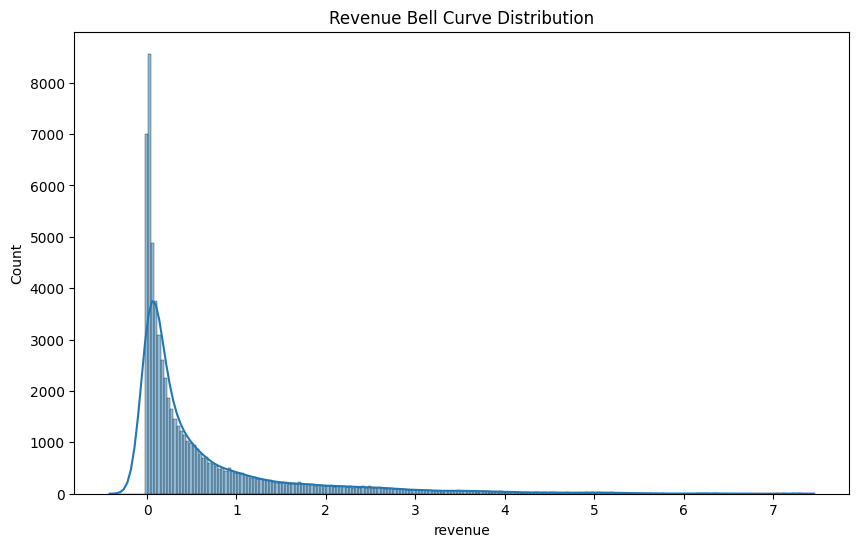

In [129]:
plt.figure(figsize=(10, 6))

# log transformation to better visualize the distribution
sns.histplot(np.log1p(revenue_by_song_per_month['revenue']), kde=True)
plt.title('Revenue Bell Curve Distribution')
plt.show()

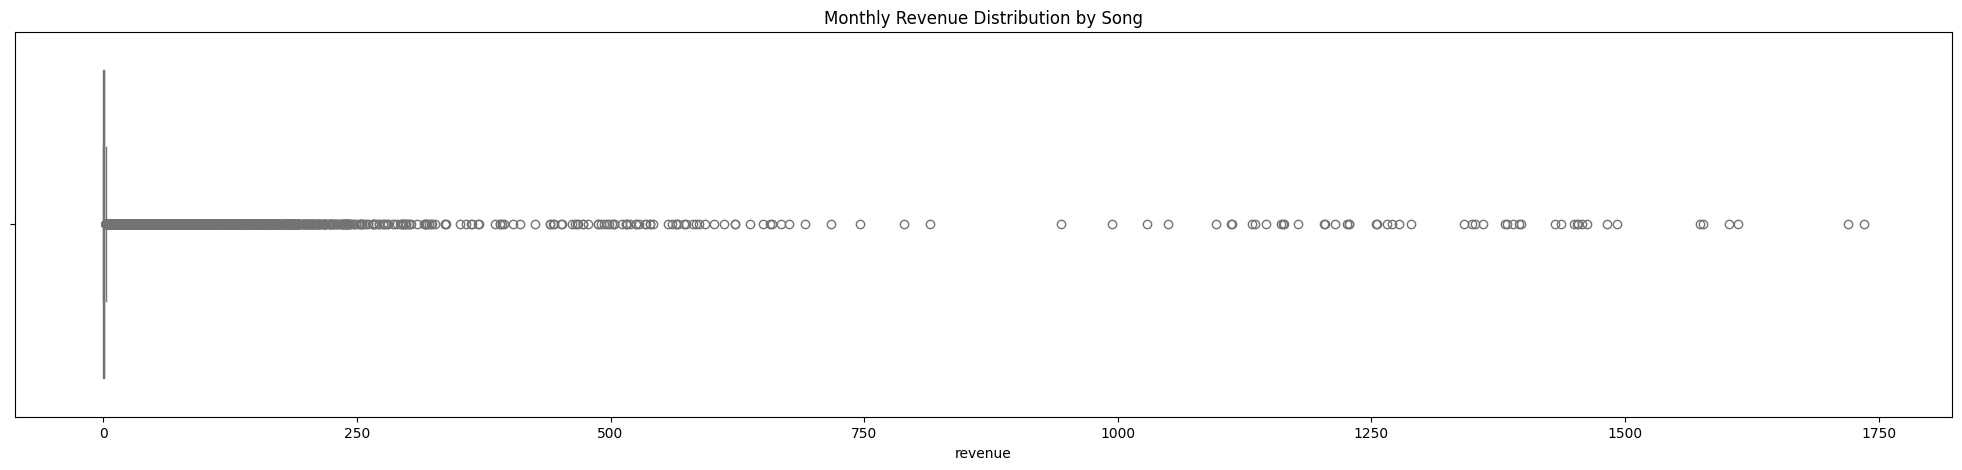

In [130]:
plt.figure(figsize=(25, 5))
sns.boxplot(data=revenue_by_song_per_month, x='revenue', color='lightgreen')

plt.title('Monthly Revenue Distribution by Song')
plt.show()

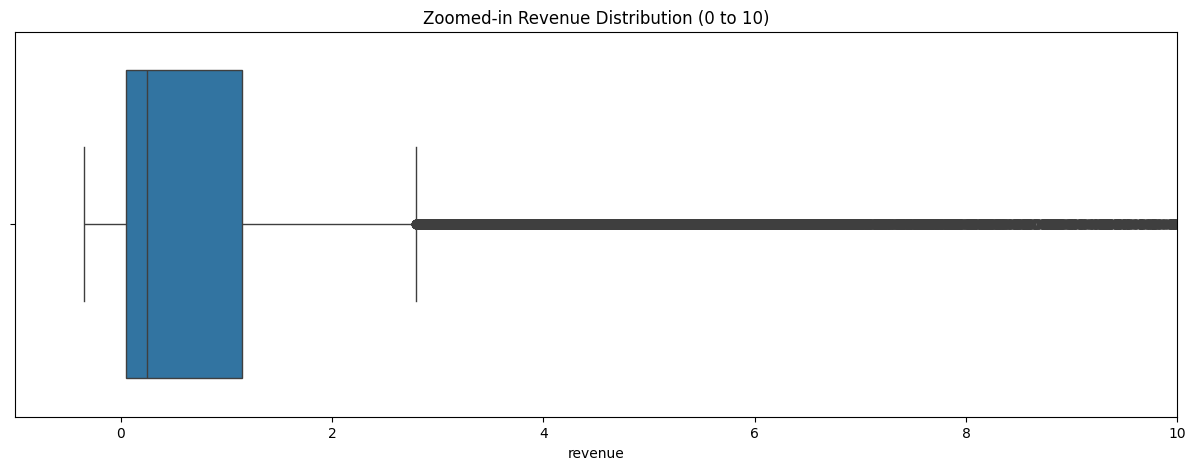

In [131]:
# Limit the view to where the bulk of the data is
plt.figure(figsize=(15, 5))
sns.boxplot(x=revenue_by_song_per_month['revenue'])
plt.xlim(-1, 10) 
plt.title('Zoomed-in Revenue Distribution (0 to 10)')
plt.show()

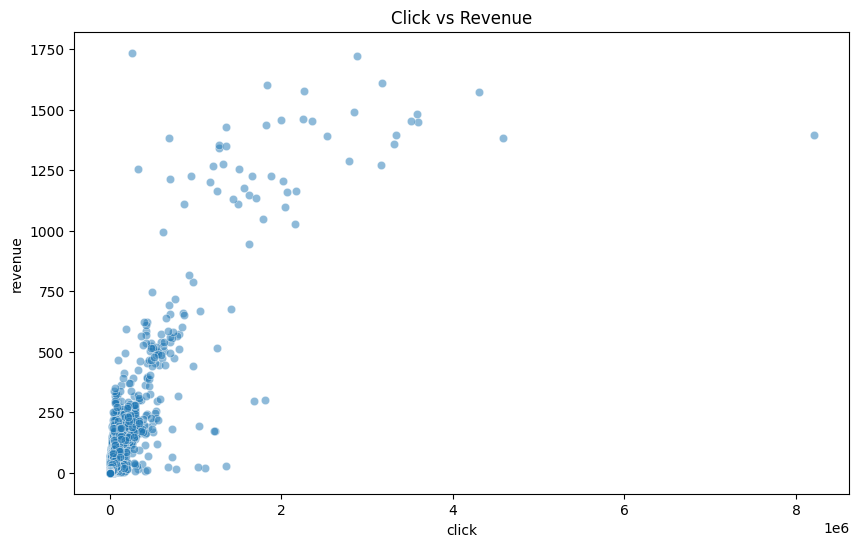

In [132]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=revenue_by_song_per_month, x='click', y='revenue', alpha=0.5)
plt.title('Click vs Revenue')
plt.show()

### Top 20 songs

In [133]:
monthly_revenue_top_song = revenue_by_song_per_month[revenue_by_song_per_month['ISRC'].isin(top_song_list)]
monthly_revenue_top_song = monthly_revenue_top_song.sort_values('YearMonth')
monthly_revenue_top_song

,ISRC,YearMonth,song,artist,click,revenue,standard_song
2706,HK-G63-18-60023,2022-01,相認,"任劍輝, 白雪仙",34095.00,95.31,相認
43553,HK-G63-18-96029,2022-01,從不放棄,鄭少秋,81739.00,52.79,從不放棄
39278,HK-G63-18-95019,2022-01,天地情緣,溫兆倫,572997.00,444.28,天地情緣
38648,HK-G63-18-95001,2022-01,笑看風雲,鄭少秋,2063868.00,1161.16,笑看風雲
33158,HK-G63-18-92001,2022-01,隨緣,溫兆倫,236809.00,123.65,隨緣
...,...,...,...,...,...,...,...
4594,HK-G63-18-74001,2025-09,啼笑姻緣,仙杜拉,77011.00,105.22,啼笑姻緣
2750,HK-G63-18-60023,2025-09,相認,"任劍輝, 白雪仙",40169.00,182.82,相認
39322,HK-G63-18-95019,2025-09,天地情緣,溫兆倫,118422.00,66.51,天地情緣
13241,HK-G63-18-79001,2025-09,楚留香,鄭少秋,217032.00,231.82,楚留香


In [134]:
monthly_revenue_top_song.describe()

,click,revenue
count,900.00,900.00
mean,269034.56,223.70
std,576831.95,297.84
min,3042.00,10.39
25%,45747.00,75.43
50%,103445.50,134.53
75%,219121.75,206.11
max,8211663.00,1735.81


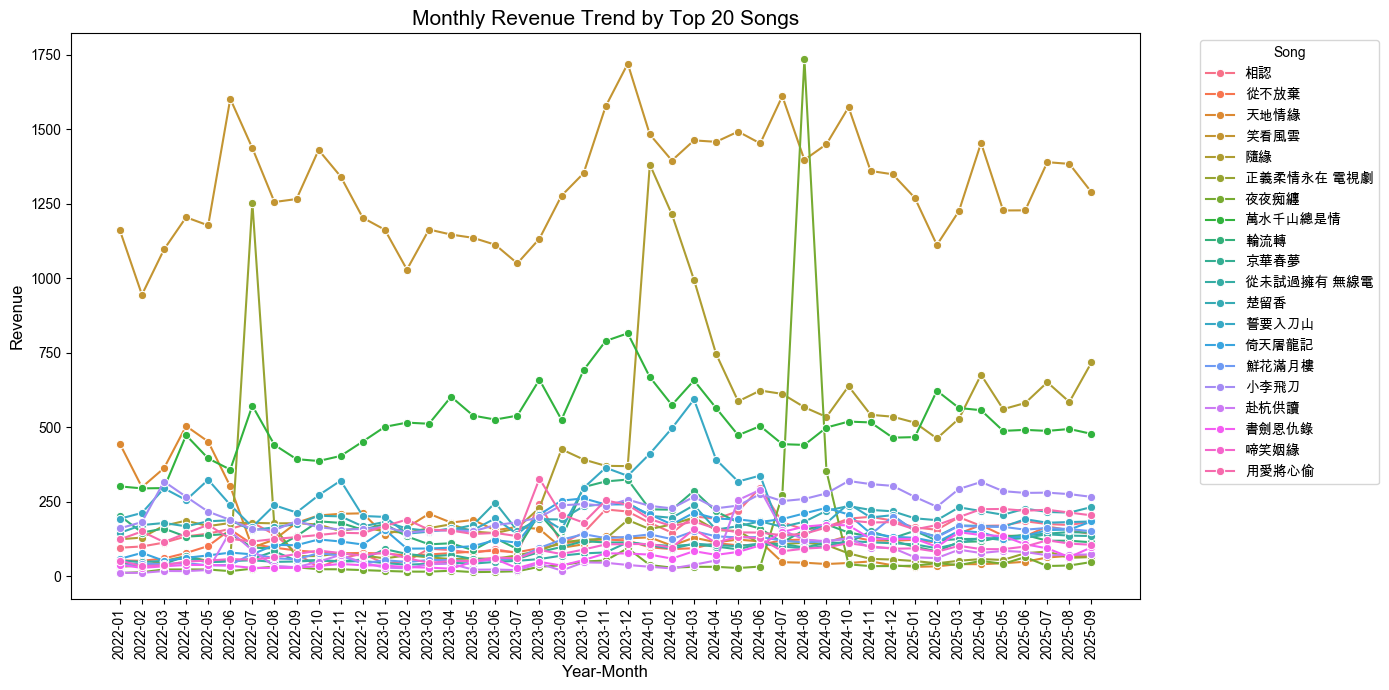

In [135]:
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 7))

sns.lineplot(data=monthly_revenue_top_song, x='YearMonth', y='revenue', hue='standard_song', marker='o')
plt.title(f'Monthly Revenue Trend by Top {ntop} Songs', fontsize=15)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=90)

# put the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Song')


plt.tight_layout()
plt.show()

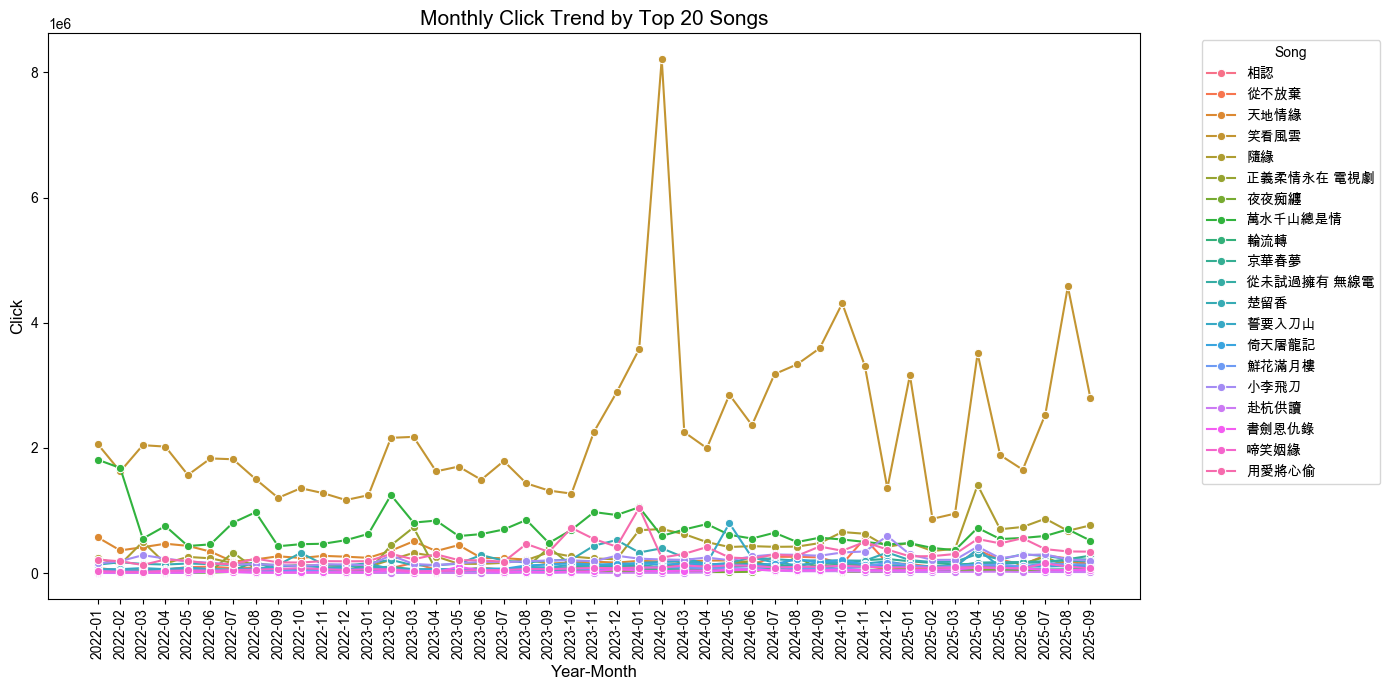

In [136]:
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 7))

sns.lineplot(data=monthly_revenue_top_song, x='YearMonth', y='click', hue='standard_song', marker='o')

plt.title(f'Monthly Click Trend by Top {ntop} Songs', fontsize=15)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Click', fontsize=12)

plt.xticks(rotation=90)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Song')

plt.tight_layout()
plt.show()

In [137]:
import plotly.express as px
import nbformat

fig = px.line(monthly_revenue_top_song, x="YearMonth", y="revenue", color="standard_song", title="圖")
fig.show()

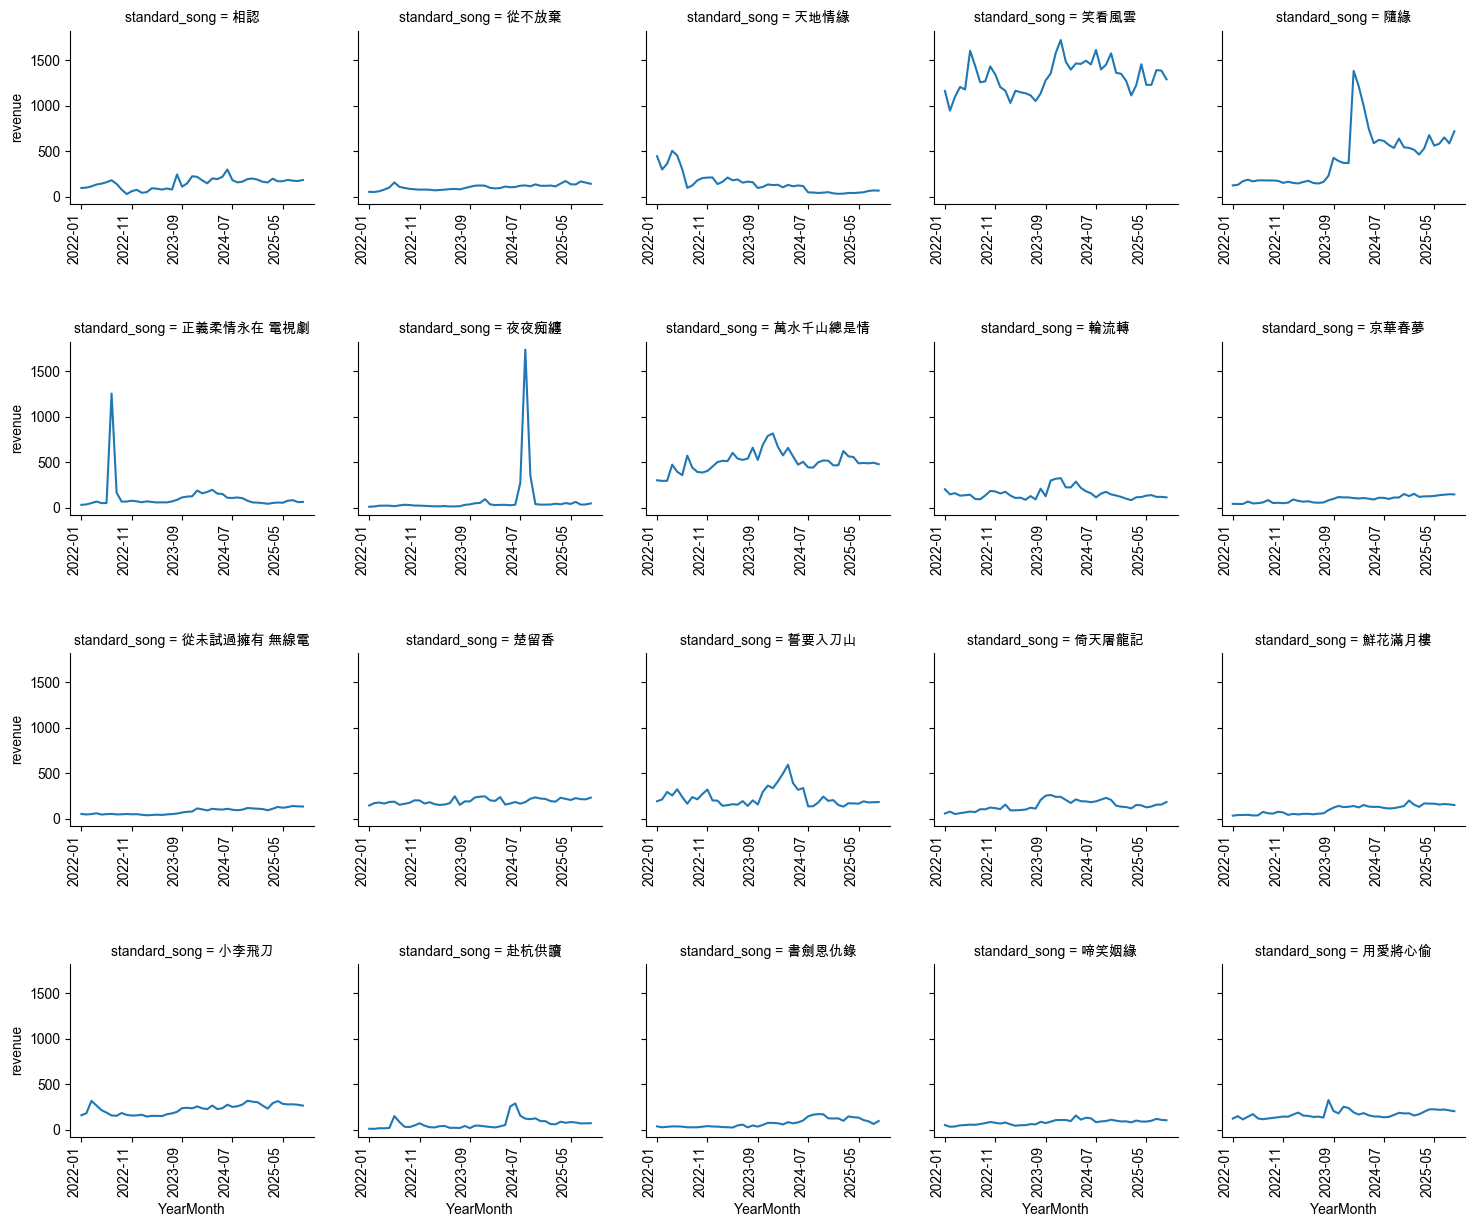

In [138]:
import matplotlib.ticker as ticker

# col='song' 會幫每一首歌切出一個子圖
# col_wrap=4 代表每橫列顯示 4 張小圖
g = sns.FacetGrid(monthly_revenue_top_song, col="standard_song", col_wrap=5, height=3, sharey=True)
g.map(sns.lineplot, "YearMonth", "revenue")

# 旋轉 X 軸標籤避免擠在一起
for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    plt.setp(ax.get_xticklabels(), rotation=90, horizontalalignment='right')

plt.subplots_adjust(hspace=0.8)
# plt.tight_layout()
plt.show()

### Revenue by Region

In [139]:
df_cleaned.head()

,Reporting Month,Platform,Label Name,Sales Type,Client Payment Currency,Unit Price,Mechanical Fee,Gross Revenue,Client Share Rate,ISRC,...,Track title,Artist Name,Release title,Country/Region,Quantity,Net Revenue,Sales Month,Release Type,source_file,YearMonth
0,2024-07-01,YouTube Official Content,CROWN MUSIC ENTERTAINMENT (HK) LIMITED,Stream,USD,0.00,0.00,0.00,0.80,HK-W63-18-00308,...,胡不歸之哭墳,薛覺先,薛覺先〈胡不歸之哭墳〉MV｜娛樂唱片,Viet Nam,2.00,0.00,2024-01-07,Music Video,2168845_770982_20240701_20240930.xlsx,2024-07
1,2024-07-01,Facebook / Instagram,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-77005,...,乘風破浪,楊詩蒂,狂潮,Philippines,4.00,0.00,2024-01-06,Music Release,2168845_770982_20240701_20240930.xlsx,2024-07
2,2024-07-01,YouTube Official Content,豐華娛樂唱片,Stream,USD,0.00,0.00,0.01,0.80,HK-G63-18-96029,...,從不放棄,鄭少秋,天地男兒,Slovakia,2.00,0.01,2024-01-07,Music Release,2168845_770982_20240701_20240930.xlsx,2024-07
3,2024-07-01,Facebook / Instagram,豐華娛樂唱片,Stream,USD,0.00,0.00,0.00,0.80,HK-G63-18-82039,...,萬水千山總是情,汪明荃,娛樂千禧精選,Slovakia,27.00,0.00,2024-01-06,Music Release,2168845_770982_20240701_20240930.xlsx,2024-07
4,2024-07-01,Apple Music,豐華娛樂唱片,Stream,USD,0.01,0.00,0.01,0.80,HK-G63-18-81058,...,勸君把淚收,汪明荃,楊門女將,Sweden,1.00,0.01,2024-01-07,Music Release,2168845_770982_20240701_20240930.xlsx,2024-07


In [140]:
df_cleaned.columns

Index(['Reporting Month', 'Platform', 'Label Name', 'Sales Type',
       'Client Payment Currency', 'Unit Price', 'Mechanical Fee',
       'Gross Revenue', 'Client Share Rate', 'ISRC', 'UPC', 'Track title',
       'Artist Name', 'Release title', 'Country/Region', 'Quantity',
       'Net Revenue', 'Sales Month', 'Release Type', 'source_file',
       'YearMonth'],
      dtype='object')

In [141]:
revenue_by_region = (
    df_cleaned
        .groupby('Country/Region')
        .agg(
            click=('Quantity','sum'),
            revenue=('Net Revenue','sum')
        )
        .sort_values('revenue', ascending=False)
        .reset_index()
)

In [142]:
revenue_by_region['revenue'].describe()

count     209.00
mean     1677.17
std      9598.86
min        -0.00
25%         0.04
50%         1.28
75%        25.78
max     92902.31
Name: revenue, dtype: float64

In [143]:
import plotly.express as px

temp_df = revenue_by_region.copy()


# 或只保留 >0
temp_df = temp_df[temp_df["revenue"] > 0]

# 假設你的 DataFrame 叫做 revenue_by_region
# 且已經 reset_index()，包含 'Country/Region' 和 'revenue' 兩個欄位
fig = px.choropleth(
    temp_df,
    locations="Country/Region",      # 指定包含國家名稱的欄位
    locationmode="country names",    # 告訴 Plotly 這是國家名稱（非縮寫代碼）
    color="revenue",                 # 顏色深淺根據營收決定
    hover_name="Country/Region",     # 滑鼠移過去顯示國家名
    color_continuous_scale="Viridis", # 設定顏色色階
    title="全球各地區營收分佈圖"
)

fig.update_geos(
    showland=True,
    landcolor="lightgray"
)

# fig = px.scatter_geo(
#     temp_df,
#     locations="Country/Region",
#     locationmode="country names",
#     size="revenue",
#     hover_name="Country/Region"
# )


fig.show()

/var/folders/hg/5j5mzy6x2ps4l676cl2hpt_r0000gn/T/ipykernel_26119/2102622595.py:11: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [144]:
us_data = df_cleaned[df_cleaned['Country/Region'] == 'United States']
max_rev_US = (
    us_data
    .groupby('ISRC')
    .agg(
        song = ('Release title', 'first'),
        artist = ('Artist Name', 'first'),
        revenue = ('Net Revenue', 'sum')
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)
max_rev_US = max_rev_US[max_rev_US['revenue'] > 100]

In [145]:
max_rev_US

,ISRC,song,artist,revenue
0,HK-G63-18-95001,笑看風雲,鄭少秋,14545.98
1,HK-G63-18-82039,萬水千山總是情,汪明荃,6758.69
2,HK-G63-18-92001,我是情痴 / 隨緣,溫兆倫,4552.81
3,HK-G63-18-78001,小李飛刀,羅文,2822.62
4,HK-G63-18-78055,娛樂經典 II 輝煌再現,鄭少秋,2714.78
...,...,...,...,...
112,HK-G63-18-79049,鄭少秋精選,鄭少秋,110.89
113,HK-G63-18-80030,萬水千山總是情,汪明荃,108.39
114,HK-G63-18-78031,強人,羅文,102.89
115,HK-G63-18-93002,大時代,鄭少秋,101.62
